# COOX — Outskirt Booking Analysis & Geo-Blocking Strategy

**Problem:** COOX receives bookings from locations outside serviceable areas (typically city outskirts or beyond operational limits). Since these bookings cannot be fulfilled, they are eventually cancelled and refunded — leading to revenue loss and poor customer experience.

**Objective:** Analyze recent historical booking data to identify geographical clusters where such non-serviceable bookings are most frequent, extract corresponding pin codes, and proactively block these areas to prevent future bookings.

---

| # | Deliverable | Description |
|---|-------------|-------------|
| 1 | Data Analysis | Distribution of outskirt bookings, city-wise trends, problem areas |
| 2 | Geospatial Mapping | Scatter maps, heat maps, cluster maps |
| 3 | Cluster Identification | DBSCAN-based density clustering with parameter justification |
| 4 | Pincode Extraction | Reverse geocoding of cluster centroids |
| 5 | Geo-Blocking Recommendation | Prioritized list of pin codes to block |

---
## 1. Setup & Data Loading

In [4]:
!pip install geopy -q

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [6]:
df = pd.read_csv('IIT Roorkee __ COOX - Raw Data.csv')
print(f'Dataset Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Dataset Shape: (557, 10)
Columns: ['Booking ID', 'Payment Status', 'Address ID', 'Address Type', 'Area', 'City', 'State', 'Country', 'Lat', 'Long']


,Booking ID,Payment Status,Address ID,Address Type,Area,City,State,Country,Lat,Long
0,509103,refunded_full,152622,Home,byalalu village chunchanaguppe post,Bengaluru,Karnataka,India,12.897291,77.375508
1,700991,refunded_full,208569,Farmhouse,Outside Hyderabad,Hyderabad,Telangana,India,16.969071,78.518297
2,717282,refunded_full,216864,Office,"Aawasari Phata Manchar, Taluka Ambegaon, Mahar...",Pune,Maharashtra,India,18.979685,73.947376
3,717285,refunded_full,216864,Office,"Aawasari Phata Manchar, Taluka Ambegaon, Mahar...",Pune,Maharashtra,India,18.979685,73.947376
4,717290,refunded_full,216864,Office,"Aawasari Phata Manchar, Taluka Ambegaon, Mahar...",Pune,Maharashtra,India,18.979685,73.947376


---
## 2. Data Cleaning & Preprocessing

In [7]:
# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print('Cleaned columns:', list(df.columns))

Cleaned columns: ['booking_id', 'payment_status', 'address_id', 'address_type', 'area', 'city', 'state', 'country', 'lat', 'long']


In [8]:
# Missing values check
print('Missing Values:')
print(df.isnull().sum())
print(f'\nRows with missing coordinates: {df[["lat","long"]].isnull().any(axis=1).sum()}')

Missing Values:
booking_id         0
payment_status     0
address_id         0
address_type       6
area               9
city               0
state              0
country            0
lat               11
long              11
dtype: int64

Rows with missing coordinates: 11


In [9]:
# Convert coordinate columns and drop invalid rows
df['lat'] = pd.to_numeric(df['lat'], errors='coerce')
df['long'] = pd.to_numeric(df['long'], errors='coerce')

rows_before = len(df)
df = df.dropna(subset=['lat', 'long'])
print(f'Dropped {rows_before - len(df)} rows with missing coordinates')
print(f'Working dataset: {len(df)} bookings')

Dropped 11 rows with missing coordinates
Working dataset: 546 bookings


In [10]:
# Duplicate check
print(f'Duplicate rows: {df.duplicated().sum()}')
print(f'Duplicate Booking IDs: {df["booking_id"].duplicated().sum()}')

Duplicate rows: 0
Duplicate Booking IDs: 0


---
## 3. Exploratory Data Analysis

Key question: Where are these non-serviceable bookings concentrated — by city, area, and address type?

In [11]:
# Confirm: all bookings are refunded
print('Payment Status Distribution:')
print(df['payment_status'].value_counts())
print(f'\nConfirmed: 100% of bookings are "{df["payment_status"].unique()[0]}" — entire dataset represents non-serviceable outskirt orders.')

Payment Status Distribution:
payment_status
refunded_full    546
Name: count, dtype: int64

Confirmed: 100% of bookings are "refunded_full" — entire dataset represents non-serviceable outskirt orders.


In [12]:
# City-wise outskirt booking breakdown
city_counts = df['city'].value_counts()
city_pct = df['city'].value_counts(normalize=True) * 100

city_summary = pd.DataFrame({
    'Booking Count': city_counts,
    'Percentage (%)': city_pct.round(2)
})
print('City-wise Outskirt Bookings:')
city_summary

City-wise Outskirt Bookings:


,Booking Count,Percentage (%)
city,,
Bengaluru,143,26.19
Pune,94,17.22
Hyderabad,68,12.45
Chennai,66,12.09
Ahmedabad,38,6.96
Jaipur,25,4.58
Kolkata,18,3.30
Surat,15,2.75
Navi Mumbai,14,2.56


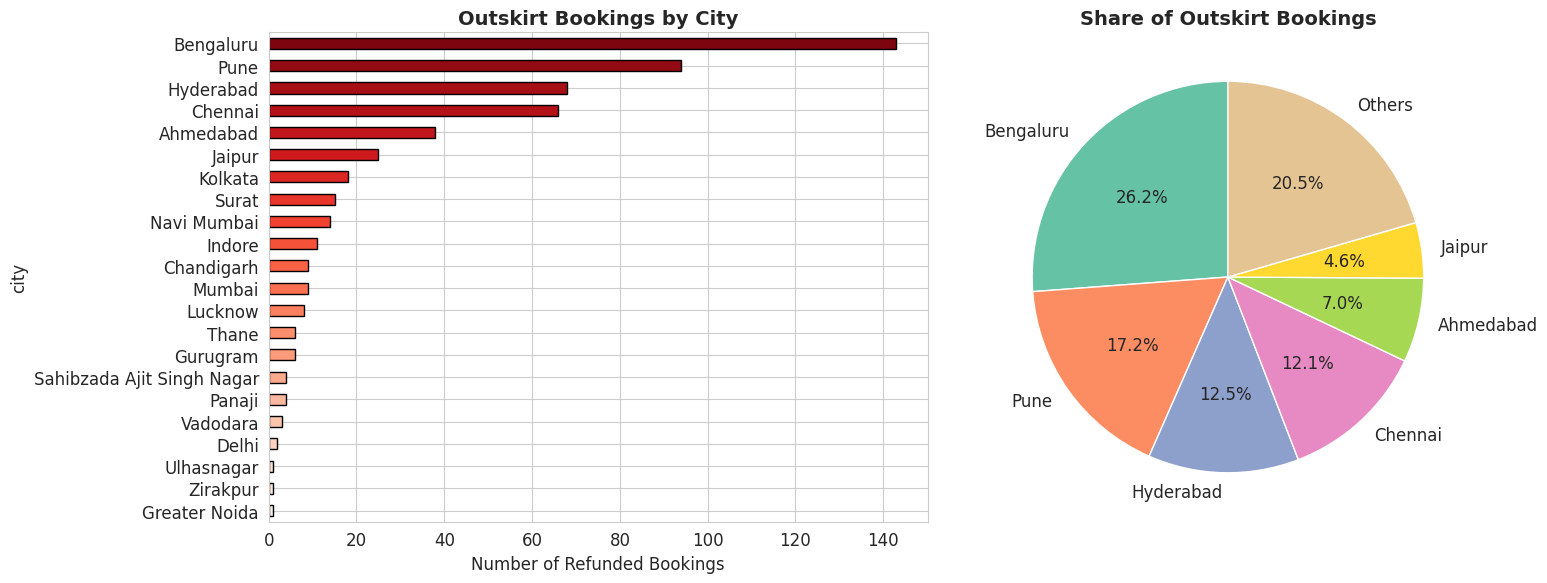

In [13]:
# City-wise distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = sns.color_palette('Reds_r', n_colors=len(city_counts))
city_counts.plot(kind='barh', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Outskirt Bookings by City', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Refunded Bookings')
axes[0].invert_yaxis()

top_cities = city_counts.head(6)
other = city_counts.iloc[6:].sum()
pie_data = pd.concat([top_cities, pd.Series({'Others': other})])
pie_data.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90,
              colors=sns.color_palette('Set2', len(pie_data)))
axes[1].set_title('Share of Outskirt Bookings', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [14]:
# State-wise distribution
print('State-wise Distribution:')
print(df['state'].value_counts())

State-wise Distribution:
state
Karnataka         143
Maharashtra       124
Telangana          68
Tamil Nadu         66
Gujarat            56
Rajasthan          25
West Bengal        18
Punjab             12
Madhya Pradesh     11
Uttar Pradesh       9
Haryana             6
Goa                 4
Chandigarh          2
Delhi               2
Name: count, dtype: int64


In [15]:
# Address type breakdown
addr_type = df['address_type'].value_counts()
addr_pct = df['address_type'].value_counts(normalize=True) * 100

print('Address Type Distribution:')
pd.DataFrame({'Count': addr_type, 'Percentage (%)': addr_pct.round(2)})

Address Type Distribution:


,Count,Percentage (%)
address_type,,
Home,441,80.77
Farmhouse,75,13.74
Other,11,2.01
Resort,10,1.83
Office,9,1.65


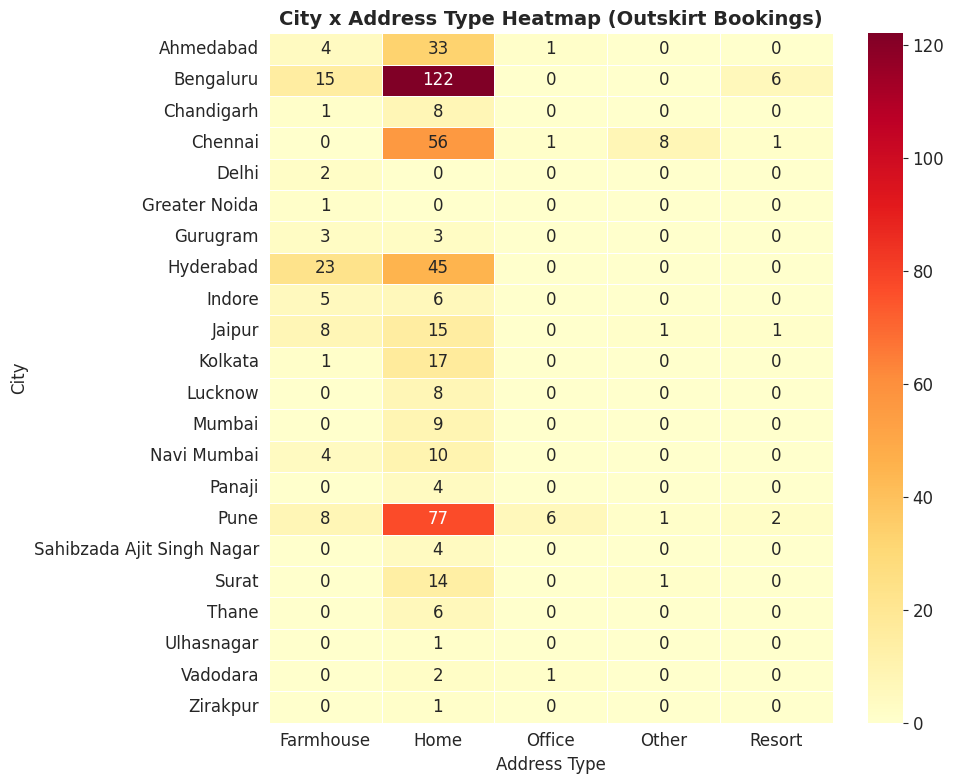

In [16]:
# Cross-tabulation: City x Address Type
ct = pd.crosstab(df['city'], df['address_type'])

plt.figure(figsize=(10, 8))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('City x Address Type Heatmap (Outskirt Bookings)', fontsize=14, fontweight='bold')
plt.xlabel('Address Type')
plt.ylabel('City')
plt.tight_layout()
plt.show()

In [17]:
# Top 20 problem areas by booking count
top_areas = df['area'].value_counts().head(20)
print('Top 20 Problem Areas:')
print(top_areas)

top10_count = df['area'].value_counts().head(10).sum()
print(f'\nTop 10 areas account for {top10_count}/{len(df)} = {(top10_count/len(df)*100):.1f}% of all outskirt bookings')

Top 20 Problem Areas:
area
Pal Tp 16                                               8
SUPERCITY GLORY, Supercity, Gujarat 382722              7
Maraimalai Nagar                                        4
Brigade El Dorado, Aerospace Park                       4
Beside lane Mittal dairy                                4
Bicholi Mardana, Ambamoliya-Bicholi Hapsi Rd            3
Harapanahalli Jigani Hobli, Anekal, Taluk               3
Weaver Colony Anekal, Karnataka 562106                  3
Manghar, Panvel                                         3
Aawasari Phata Manchar, Taluka Ambegaon, Maharashtra    3
Moinabad                                                3
Reddiar Garden, Kamaraj Nagar, Avadi,                   3
Moraiya, Gujarat 382213                                 3
Village Dantali                                         3
Gokulapuram, Chengalpattu                               3
Bommasandra Industrial Area, Bommasandra                3
Guru Nanak Colony Rd, Guru Nanak Colony      

In [18]:
# Repeat offender addresses
repeat_addresses = df['address_id'].value_counts()
repeat_addresses = repeat_addresses[repeat_addresses > 1]

print(f'Addresses with multiple outskirt bookings: {len(repeat_addresses)}')
print(f'Total bookings from repeat addresses: {repeat_addresses.sum()}')
print(f'\nTop 10 repeat addresses:')

for addr_id in repeat_addresses.head(10).index:
    addr_data = df[df['address_id'] == addr_id].iloc[0]
    print(f'  Address ID {addr_id}: {repeat_addresses[addr_id]} bookings -- {addr_data["area"]}, {addr_data["city"]}')

Addresses with multiple outskirt bookings: 68
Total bookings from repeat addresses: 170

Top 10 repeat addresses:
  Address ID 471022: 8 bookings -- Pal Tp 16, Surat
  Address ID 610514: 7 bookings -- SUPERCITY GLORY, Supercity, Gujarat 382722, Ahmedabad
  Address ID 409419: 4 bookings -- Beside lane Mittal dairy, Pune
  Address ID 612072: 4 bookings -- Brigade El Dorado, Aerospace Park, Bengaluru
  Address ID 573580: 3 bookings -- Guru Nanak Colony Rd, Guru Nanak Colony, Chandigarh
  Address ID 641962: 3 bookings -- Reddiar Garden, Kamaraj Nagar, Avadi,, Chennai
  Address ID 417624: 3 bookings -- Mambakkam - Medavakkam Main Rd,, Chennai
  Address ID 545262: 3 bookings -- Bommasandra Industrial Area, Bommasandra, Bengaluru
  Address ID 649000: 3 bookings -- Harapanahalli Jigani Hobli, Anekal, Taluk, Bengaluru
  Address ID 600448: 3 bookings -- Palaka Uttar Pradesh, Lucknow


### EDA Key Findings

1. **100% of the dataset is refunded bookings** — confirming these are all non-serviceable outskirt orders
2. **Bengaluru dominates** with the highest number of outskirt bookings, followed by Pune and Hyderabad
3. **Home is the primary address type** — customers ordering to residential addresses in outskirts
4. **Repeat offenders exist** — same addresses generating multiple failed bookings
5. **Top 10 problem areas account for a significant share** of all outskirt bookings

### 3.1 Distance from City Center Analysis

To quantify how far outside the serviceable zone each booking falls, we dynamically resolve each city's official center coordinates using Nominatim (OpenStreetMap), then compute the haversine distance for every booking. This provides a data-driven definition of 'outskirt' rather than a subjective label.

In [19]:
# Resolve city center coordinates dynamically via Nominatim
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from math import radians, sin, cos, sqrt, atan2

geo = Nominatim(user_agent='coox_city_center_v1', timeout=10)
geocode = RateLimiter(geo.geocode, min_delay_seconds=1.5)

unique_cities = df['city'].unique()
city_centers = {}

print('Resolving city center coordinates...')
for city in unique_cities:
    try:
        loc = geocode(f'{city}, India')
        if loc:
            city_centers[city] = (loc.latitude, loc.longitude)
            print(f'  {city}: ({loc.latitude:.4f}, {loc.longitude:.4f})')
        else:
            # Fallback: use median of booking coordinates for that city
            c_df = df[df['city'] == city]
            city_centers[city] = (c_df['lat'].median(), c_df['long'].median())
            print(f'  {city}: FALLBACK to median ({city_centers[city][0]:.4f}, {city_centers[city][1]:.4f})')
    except Exception as e:
        c_df = df[df['city'] == city]
        city_centers[city] = (c_df['lat'].median(), c_df['long'].median())
        print(f'  {city}: ERROR, fallback to median -- {str(e)[:50]}')

print(f'\nResolved {len(city_centers)} city centers.')

Resolving city center coordinates...
  Bengaluru: (12.9768, 77.5901)
  Hyderabad: (17.3606, 78.4741)
  Pune: (18.5214, 73.8545)
  Jaipur: (26.9155, 75.8190)
  Ahmedabad: (23.0215, 72.5801)
  Indore: (22.7204, 75.8682)
  Thane: (19.3654, 73.3685)
  Gurugram: (28.4646, 77.0299)
  Sahibzada Ajit Singh Nagar: (30.7041, 76.7177)
  Mumbai: (19.0550, 72.8692)
  Chennai: (13.0837, 80.2702)
  Surat: (21.2095, 72.8317)
  Navi Mumbai: (19.0308, 73.0199)
  Ulhasnagar: (19.2236, 73.1672)
  Zirakpur: (30.6557, 76.8201)
  Vadodara: (22.2973, 73.1943)
  Kolkata: (22.5726, 88.3639)
  Chandigarh: (30.7334, 76.7797)
  Panaji: (15.4990, 73.8282)
  Greater Noida: (28.4671, 77.5138)
  Lucknow: (26.8381, 80.9346)
  Delhi: (28.6139, 77.2090)

Resolved 22 city centers.


In [20]:
# Compute haversine distance from city center for each booking
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))

df['dist_from_center_km'] = df.apply(
    lambda r: haversine_km(
        city_centers[r['city']][0], city_centers[r['city']][1],
        r['lat'], r['long']
    ), axis=1
)

print('Distance from City Center (km):')
print(df['dist_from_center_km'].describe().round(2))
print(f'\nMedian distance: {df["dist_from_center_km"].median():.1f} km')
print(f'Max distance: {df["dist_from_center_km"].max():.1f} km')

Distance from City Center (km):
count    546.00
mean      23.63
std       12.78
min        1.34
25%       16.82
50%       21.08
75%       26.69
max      179.30
Name: dist_from_center_km, dtype: float64

Median distance: 21.1 km
Max distance: 179.3 km


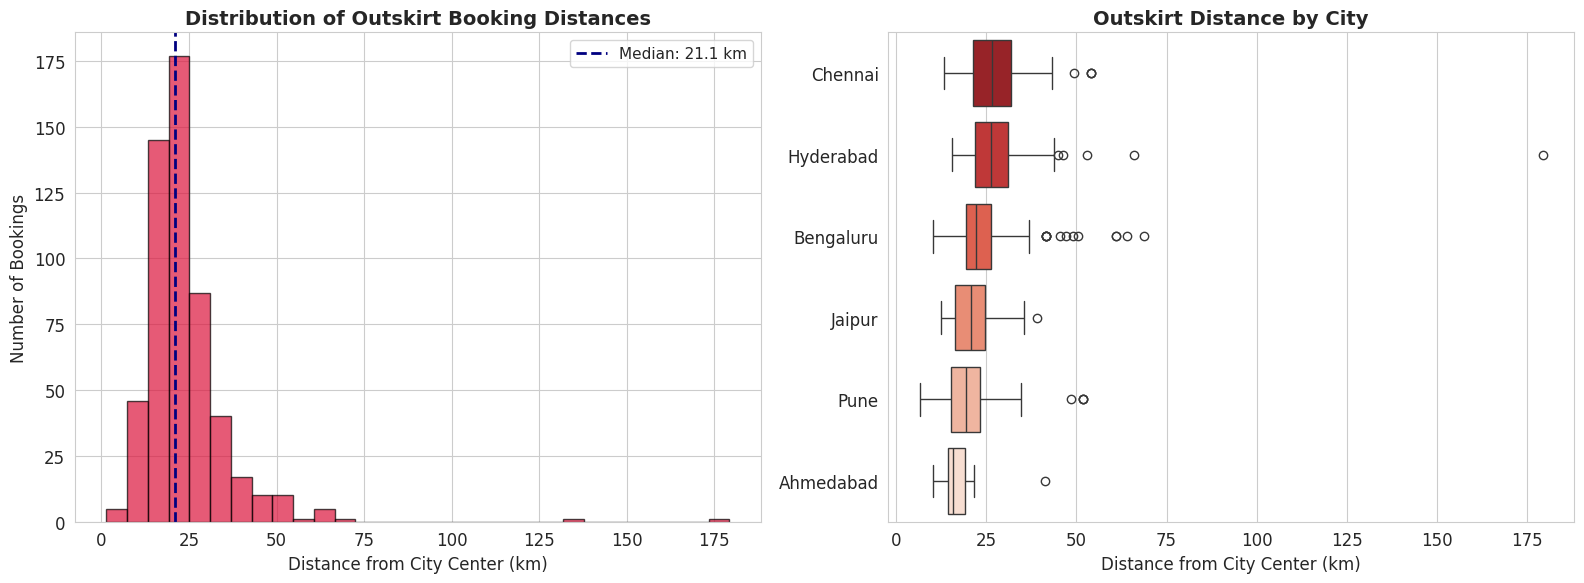

In [21]:
# Distance distribution — overall and per city
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overall distribution
axes[0].hist(df['dist_from_center_km'], bins=30, color='crimson', edgecolor='black', alpha=0.7)
axes[0].axvline(df['dist_from_center_km'].median(), color='navy', linestyle='--',
                linewidth=2, label=f'Median: {df["dist_from_center_km"].median():.1f} km')
axes[0].set_xlabel('Distance from City Center (km)', fontsize=12)
axes[0].set_ylabel('Number of Bookings', fontsize=12)
axes[0].set_title('Distribution of Outskirt Booking Distances', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)

# Per-city boxplot (top cities)
top_city_list = city_counts.head(6).index.tolist()
plot_df = df[df['city'].isin(top_city_list)]
city_order = plot_df.groupby('city')['dist_from_center_km'].median().sort_values(ascending=False).index
sns.boxplot(data=plot_df, y='city', x='dist_from_center_km', order=city_order,
            ax=axes[1], palette='Reds_r')
axes[1].set_xlabel('Distance from City Center (km)', fontsize=12)
axes[1].set_ylabel('')
axes[1].set_title('Outskirt Distance by City', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [22]:
# Recommended geo-fence radius per city
print('Recommended Geo-Fence Radius per City:')
print('=' * 70)
print(f'{"City":<20} {"Bookings":<10} {"Min (km)":<10} {"Median (km)":<12} {"P25 (km)":<10} {"Suggested Radius"}')
print('-' * 70)

geofence_data = []
for city in city_counts.head(10).index:
    c_df = df[df['city'] == city]
    d = c_df['dist_from_center_km']
    # Suggested radius = 25th percentile (blocks 75% of outskirt bookings for that city)
    suggested = d.quantile(0.25)
    print(f'{city:<20} {len(c_df):<10} {d.min():<10.1f} {d.median():<12.1f} {suggested:<10.1f} {suggested:.0f} km')
    geofence_data.append({
        'city': city,
        'bookings': len(c_df),
        'min_dist_km': round(d.min(), 1),
        'p25_dist_km': round(suggested, 1),
        'median_dist_km': round(d.median(), 1),
        'max_dist_km': round(d.max(), 1),
        'suggested_geofence_km': round(suggested, 0)
    })

geofence_df = pd.DataFrame(geofence_data)
print(f'\nInterpretation: Blocking bookings beyond the suggested radius would prevent')
print(f'approximately 75% of non-serviceable bookings per city.')

Recommended Geo-Fence Radius per City:
City                 Bookings   Min (km)   Median (km)  P25 (km)   Suggested Radius
----------------------------------------------------------------------
Bengaluru            143        10.3       22.1         19.3       19 km
Pune                 94         6.5        19.5         15.2       15 km
Hyderabad            68         15.4       26.2         22.0       22 km
Chennai              66         13.2       26.5         21.4       21 km
Ahmedabad            38         10.1       15.8         14.4       14 km
Jaipur               25         12.5       20.8         16.4       16 km
Kolkata              18         12.8       18.0         14.1       14 km
Surat                15         9.0        19.4         18.1       18 km
Navi Mumbai          14         8.8        11.3         10.5       10 km
Indore               11         10.0       20.4         11.9       12 km

Interpretation: Blocking bookings beyond the suggested radius would prevent

---
## 4. Geospatial Visualization

In [23]:
import folium
from folium.plugins import HeatMap

In [24]:
# Scatter map of all outskirt booking locations
m = folium.Map(
    location=[df['lat'].mean(), df['long'].mean()],
    zoom_start=5,
    tiles='CartoDB positron'
)

for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['long']],
        radius=3,
        color='crimson',
        fill=True,
        fill_opacity=0.5,
        popup=f"{row['area']}, {row['city']}<br>Type: {row['address_type']}<br>Booking: {row['booking_id']}"
    ).add_to(m)

m

In [25]:
# Heatmap — booking density visualization
m_heat = folium.Map(
    location=[df['lat'].mean(), df['long'].mean()],
    zoom_start=5,
    tiles='CartoDB dark_matter'
)

HeatMap(
    df[['lat', 'long']].values.tolist(),
    radius=15,
    blur=10,
    max_zoom=13,
    gradient={0.2: 'blue', 0.4: 'lime', 0.6: 'yellow', 0.8: 'orange', 1: 'red'}
).add_to(m_heat)

m_heat

### 4.1 City-Level Heatmaps

India-wide maps obscure local patterns. The following maps zoom into the top 3 problem cities to reveal the spatial distribution of outskirt bookings at street level.

In [26]:
# City-level zoomed heatmaps for top 3 cities
top_3_cities = city_counts.head(3).index.tolist()

for city_name in top_3_cities:
    city_df = df[df['city'] == city_name]
    center_lat = city_df['lat'].mean()
    center_long = city_df['long'].mean()

    m_city = folium.Map(
        location=[center_lat, center_long],
        zoom_start=11,
        tiles='CartoDB positron'
    )

    # Add heatmap layer
    HeatMap(
        city_df[['lat', 'long']].values.tolist(),
        radius=18,
        blur=12,
        max_zoom=15,
        gradient={0.2: 'blue', 0.4: 'cyan', 0.6: 'yellow', 0.8: 'orange', 1: 'red'}
    ).add_to(m_city)

    # Add individual markers
    for _, row in city_df.iterrows():
        folium.CircleMarker(
            location=[row['lat'], row['long']],
            radius=4,
            color='darkred',
            fill=True,
            fill_opacity=0.6,
            popup=f"{row['area']}<br>Type: {row['address_type']}"
        ).add_to(m_city)

    print(f'--- {city_name} ({len(city_df)} outskirt bookings) ---')
    display(m_city)

--- Bengaluru (143 outskirt bookings) ---


--- Pune (94 outskirt bookings) ---


--- Hyderabad (68 outskirt bookings) ---


---
## 5. Cluster Identification (DBSCAN)

**Why DBSCAN?**
- Does not require pre-specifying the number of clusters (unlike K-Means)
- Can find arbitrarily shaped clusters (outskirt zones are not circular)
- Automatically identifies noise/outlier points
- Works natively with haversine distance for geographic coordinates

In [27]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

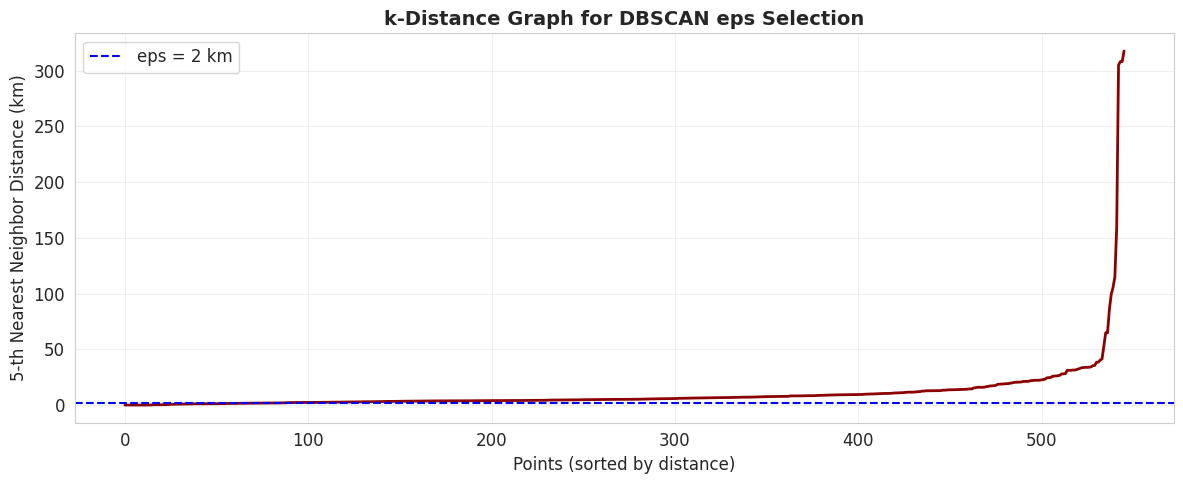

Selected eps = 2 km (based on elbow in k-distance plot)
Selected min_samples = 5 (standard minimum for geographic clustering)


In [28]:
# k-Distance plot for optimal eps selection
coords = df[['lat', 'long']].to_numpy()
kms_per_radian = 6371.0088

k = 5
neighbors = NearestNeighbors(n_neighbors=k, metric='haversine')
neighbors.fit(np.radians(coords))
distances, _ = neighbors.kneighbors(np.radians(coords))
k_distances = np.sort(distances[:, -1]) * kms_per_radian

plt.figure(figsize=(12, 5))
plt.plot(k_distances, color='darkred', linewidth=2)
plt.xlabel('Points (sorted by distance)', fontsize=12)
plt.ylabel(f'{k}-th Nearest Neighbor Distance (km)', fontsize=12)
plt.title('k-Distance Graph for DBSCAN eps Selection', fontsize=14, fontweight='bold')
plt.axhline(y=2, color='blue', linestyle='--', linewidth=1.5, label='eps = 2 km')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Selected eps = 2 km (based on elbow in k-distance plot)')
print(f'Selected min_samples = {k} (standard minimum for geographic clustering)')

In [29]:
# Run DBSCAN
eps_km = 2.0
epsilon = eps_km / kms_per_radian

db = DBSCAN(eps=epsilon, min_samples=k, metric='haversine')
df['cluster'] = db.fit_predict(np.radians(coords))

n_clusters = len(set(df['cluster'])) - (1 if -1 in df['cluster'].values else 0)
n_noise = (df['cluster'] == -1).sum()

print(f'Clusters found: {n_clusters}')
print(f'Noise points (isolated bookings): {n_noise}')
print(f'Clustered bookings: {len(df) - n_noise} / {len(df)} ({(len(df)-n_noise)/len(df)*100:.1f}%)')

Clusters found: 13
Noise points (isolated bookings): 451
Clustered bookings: 95 / 546 (17.4%)


In [30]:
# Cluster quality — Silhouette Score
df_clustered = df[df['cluster'] != -1]

if len(df_clustered['cluster'].unique()) > 1:
    sil_score = silhouette_score(
        np.radians(df_clustered[['lat', 'long']]),
        df_clustered['cluster'],
        metric='haversine'
    )
    print(f'Silhouette Score: {sil_score:.3f}')
    if sil_score > 0.5:
        print('Interpretation: Good cluster separation')
    elif sil_score > 0.25:
        print('Interpretation: Moderate cluster separation')
    else:
        print('Interpretation: Weak separation — clusters may overlap')
else:
    print('Only 1 cluster found — silhouette score not applicable')

Silhouette Score: 0.940
Interpretation: Good cluster separation


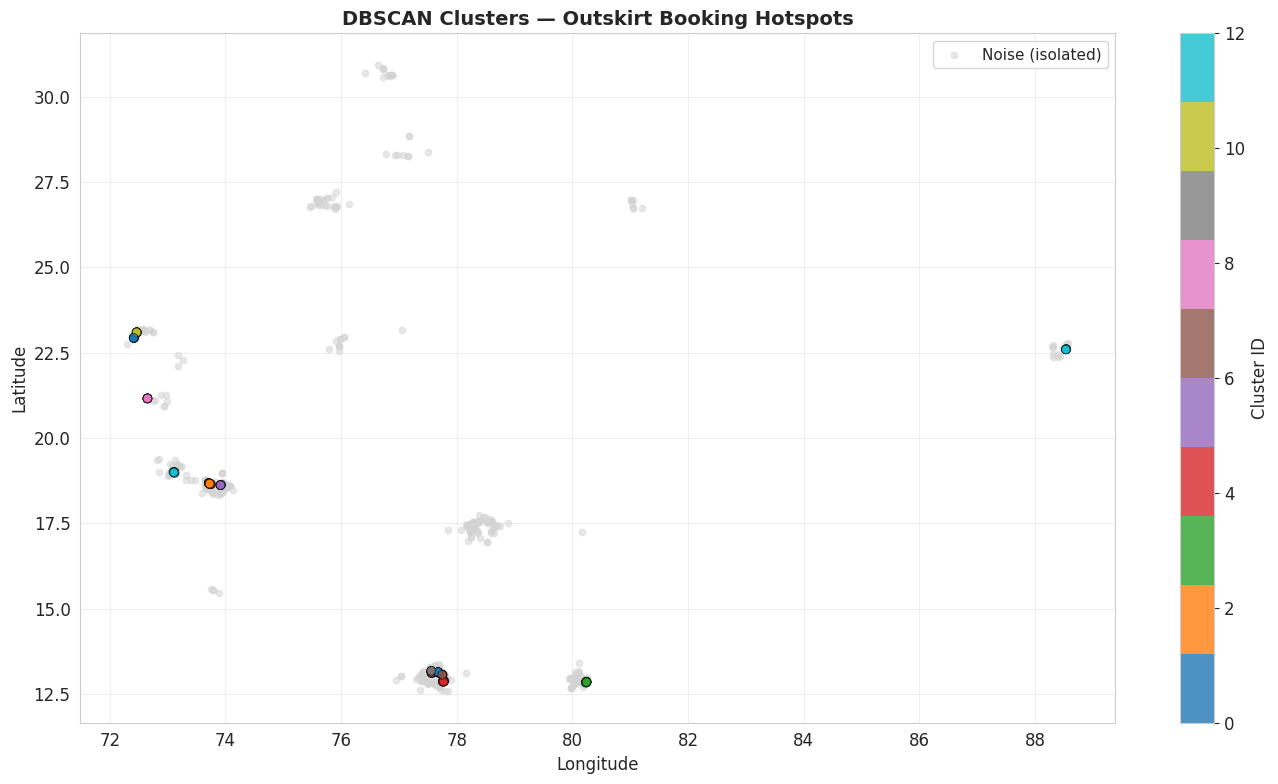

In [31]:
# Cluster scatter plot
plt.figure(figsize=(14, 8))

noise = df[df['cluster'] == -1]
plt.scatter(noise['long'], noise['lat'], c='lightgray', s=20, alpha=0.5, label='Noise (isolated)')

clustered = df[df['cluster'] != -1]
scatter = plt.scatter(
    clustered['long'], clustered['lat'],
    c=clustered['cluster'], cmap='tab10',
    s=40, edgecolors='black', linewidths=0.5, alpha=0.8
)
plt.colorbar(scatter, label='Cluster ID')
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.title('DBSCAN Clusters — Outskirt Booking Hotspots', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
# Cluster-only heatmap — density within identified hotspot zones
m_cluster_heat = folium.Map(
    location=[df['lat'].mean(), df['long'].mean()],
    zoom_start=5,
    tiles='CartoDB dark_matter'
)

# Heatmap using ONLY clustered points (excludes noise)
HeatMap(
    df_clustered[['lat', 'long']].values.tolist(),
    radius=20,
    blur=15,
    max_zoom=13,
    gradient={0.2: 'blue', 0.4: 'cyan', 0.6: 'yellow', 0.8: 'orange', 1: 'red'}
).add_to(m_cluster_heat)

# Add cluster centroid markers
cluster_centers = df_clustered.groupby('cluster')[['lat', 'long']].mean()
cluster_sizes = df_clustered['cluster'].value_counts()

for cluster_id, center in cluster_centers.iterrows():
    size = cluster_sizes[cluster_id]
    folium.Marker(
        location=[center['lat'], center['long']],
        popup=f'Cluster {cluster_id} | {size} bookings',
        icon=folium.Icon(color='red', icon='info-sign', prefix='glyphicon')
    ).add_to(m_cluster_heat)

print('Cluster-Only Heatmap (noise excluded):')
m_cluster_heat

Cluster-Only Heatmap (noise excluded):


In [33]:
# Cluster summary table
cluster_summary = df_clustered.groupby('cluster').agg(
    booking_count=('booking_id', 'count'),
    mean_lat=('lat', 'mean'),
    mean_long=('long', 'mean'),
    cities=('city', lambda x: ', '.join(x.unique())),
    top_area=('area', lambda x: x.value_counts().index[0]),
    address_types=('address_type', lambda x: ', '.join(x.unique()))
).sort_values('booking_count', ascending=False)

print('Cluster Summary:')
cluster_summary

Cluster Summary:


,booking_count,mean_lat,mean_long,cities,top_area,address_types
cluster,,,,,,
2,13,18.666380,73.725871,Pune,"K Town, near macdonnalds, mukai chowk, kevle",Home
4,10,12.872870,77.770582,Bengaluru,Sarjapur Main Road,Home
3,10,12.852611,80.241559,Chennai,"Kanathur Reddykuppam, Tamil Nadu 603112","Home, Resort"
8,8,21.160659,72.652016,Surat,Pal Tp 16,Home
6,8,13.065079,77.748390,Bengaluru,Budigere cross,Home
10,8,23.096730,72.465761,Ahmedabad,"SUPERCITY GLORY, Supercity, Gujarat 382722",Home
0,7,13.141730,77.676408,Bengaluru,"Brigade El Dorado, Aerospace Park",Home
5,6,18.623414,73.918063,Pune,"Atlantic, pride world city",Home
1,5,22.932548,72.417236,Ahmedabad,"Moraiya, Gujarat 382213","Farmhouse, Home"


In [34]:
# Tag as Outskirt Hotspots
hotspot_threshold = 5
hotspot_clusters = cluster_summary[cluster_summary['booking_count'] >= hotspot_threshold]
minor_clusters = cluster_summary[cluster_summary['booking_count'] < hotspot_threshold]

print(f'OUTSKIRT HOTSPOTS (>={hotspot_threshold} bookings): {len(hotspot_clusters)} clusters')
print(hotspot_clusters[['booking_count', 'cities', 'top_area']])
print(f'\nMinor clusters (<{hotspot_threshold} bookings): {len(minor_clusters)} clusters')

OUTSKIRT HOTSPOTS (>=5 bookings): 13 clusters
         booking_count               cities  \
cluster                                       
2                   13                 Pune   
4                   10            Bengaluru   
3                   10              Chennai   
8                    8                Surat   
6                    8            Bengaluru   
10                   8            Ahmedabad   
0                    7            Bengaluru   
5                    6                 Pune   
1                    5            Ahmedabad   
7                    5            Bengaluru   
9                    5            Bengaluru   
11                   5              Kolkata   
12                   5  Navi Mumbai, Mumbai   

                                                  top_area  
cluster                                                     
2             K Town, near macdonnalds, mukai chowk, kevle  
4                                       Sarjapur Main Road  
3   

### 5.2 City-Level Adaptive DBSCAN

India-wide DBSCAN with eps=2km clusters only a fraction of bookings because points are spread across the country. Running DBSCAN per city with adaptive eps captures more local patterns.

In [35]:
# City-Level DBSCAN with adaptive eps
city_cluster_results = []
df['city_cluster'] = -1
global_cluster_id = 0

for city_name in df['city'].unique():
    city_df = df[df['city'] == city_name]
    if len(city_df) < 3:
        continue

    city_coords = city_df[['lat', 'long']].to_numpy()
    k_city = min(3, len(city_df) - 1)

    nn = NearestNeighbors(n_neighbors=k_city, metric='haversine')
    nn.fit(np.radians(city_coords))
    dists, _ = nn.kneighbors(np.radians(city_coords))
    k_dists_km = np.sort(dists[:, -1]) * kms_per_radian

    eps_city = max(np.percentile(k_dists_km, 75), 3.0)
    eps_city = min(eps_city, 15.0)
    eps_rad = eps_city / kms_per_radian

    db_city = DBSCAN(eps=eps_rad, min_samples=k_city, metric='haversine')
    labels = db_city.fit_predict(np.radians(city_coords))

    n_cl = len(set(labels)) - (1 if -1 in labels else 0)
    n_clustered = (labels != -1).sum()

    for local_id in set(labels):
        if local_id == -1:
            continue
        idx = city_df.index[labels == local_id]
        df.loc[idx, 'city_cluster'] = global_cluster_id
        global_cluster_id += 1

    if n_cl > 0:
        city_cluster_results.append({
            'city': city_name, 'eps_km': round(eps_city, 1),
            'clusters': n_cl, 'clustered': n_clustered,
            'total': len(city_df), 'pct': round(n_clustered/len(city_df)*100, 1)
        })

city_cl_df = pd.DataFrame(city_cluster_results).sort_values('clustered', ascending=False)
total_city_clustered = (df['city_cluster'] != -1).sum()

print(f'City-Level DBSCAN Results:')
print(f'  Total clusters: {global_cluster_id}')
print(f'  Clustered: {total_city_clustered} / {len(df)} ({total_city_clustered/len(df)*100:.1f}%)')
print(f'  vs India-wide: {len(df_clustered)} / {len(df)} ({len(df_clustered)/len(df)*100:.1f}%)')
print()
city_cl_df

City-Level DBSCAN Results:
  Total clusters: 59
  Clustered: 414 / 546 (75.8%)
  vs India-wide: 95 / 546 (17.4%)



,city,eps_km,clusters,clustered,total,pct
0,Bengaluru,4.1,14,113,143,79.0
2,Pune,4.0,7,70,94,74.5
1,Hyderabad,7.4,7,54,68,79.4
9,Chennai,3.6,9,50,66,75.8
4,Ahmedabad,4.1,3,31,38,81.6
3,Jaipur,8.7,3,21,25,84.0
12,Kolkata,8.9,3,16,18,88.9
11,Navi Mumbai,4.6,3,12,14,85.7
10,Surat,15.0,1,10,15,66.7
13,Chandigarh,5.9,2,8,9,88.9


### 5.1 City-Level Cluster Maps

Zoomed views of clusters within top problem cities. Each cluster zone is highlighted with a 3km radius circle.

In [36]:
# City-level cluster maps for top 3 cities
top_3_cities = city_counts.head(3).index.tolist()

for city_name in top_3_cities:
    city_df = df[df['city'] == city_name]
    city_clustered = city_df[city_df['cluster'] != -1]
    city_noise = city_df[city_df['cluster'] == -1]

    m_city_cl = folium.Map(
        location=[city_df['lat'].mean(), city_df['long'].mean()],
        zoom_start=11,
        tiles='CartoDB positron'
    )

    # Noise points in gray
    for _, row in city_noise.iterrows():
        folium.CircleMarker(
            location=[row['lat'], row['long']],
            radius=3,
            color='gray',
            fill=True,
            fill_opacity=0.3,
            popup=f"{row['area']} (isolated)"
        ).add_to(m_city_cl)

    # Clustered points colored by cluster
    colors_list = ['red', 'blue', 'green', 'purple', 'orange', 'darkred', 'cadetblue', 'darkgreen', 'pink', 'darkblue']
    city_cluster_ids = city_clustered['cluster'].unique()

    for idx, cluster_id in enumerate(city_cluster_ids):
        cl_data = city_clustered[city_clustered['cluster'] == cluster_id]
        cl_color = colors_list[idx % len(colors_list)]
        cl_center = cl_data[['lat', 'long']].mean()

        # Draw cluster zone circle
        folium.Circle(
            location=[cl_center['lat'], cl_center['long']],
            radius=3000,
            color=cl_color,
            fill=True,
            fill_opacity=0.15,
            popup=f'Cluster {cluster_id} | {len(cl_data)} bookings'
        ).add_to(m_city_cl)

        for _, row in cl_data.iterrows():
            folium.CircleMarker(
                location=[row['lat'], row['long']],
                radius=5,
                color=cl_color,
                fill=True,
                fill_opacity=0.7,
                popup=f"Cluster {cluster_id} | {row['area']}"
            ).add_to(m_city_cl)

    total_cl = len(city_clustered)
    total_noise = len(city_noise)
    print(f'--- {city_name}: {len(city_df)} bookings | {total_cl} clustered | {total_noise} isolated ---')
    display(m_city_cl)

--- Bengaluru: 143 bookings | 35 clustered | 108 isolated ---


--- Pune: 94 bookings | 19 clustered | 75 isolated ---


--- Hyderabad: 68 bookings | 0 clustered | 68 isolated ---


---
## 6. Pincode Extraction

**Method:** Two-pronged approach:
1. Regex extraction of 6-digit Indian pincodes from address text
2. Reverse geocoding of cluster centroids using Nominatim (OpenStreetMap)

*Note: Reverse geocoding takes approximately 2-5 minutes due to API rate limiting.*

In [37]:
# Method 1: Extract pincodes from address field using regex
df['pincode_from_address'] = df['area'].astype(str).str.extract(r'(\d{6})')
pincodes_found = df['pincode_from_address'].notna().sum()
print(f'Pincodes found in address text: {pincodes_found} / {len(df)}')

if pincodes_found > 0:
    print('\nSample pincodes extracted from address field:')
    print(df[df['pincode_from_address'].notna()][['area', 'city', 'pincode_from_address']].head(15))

Pincodes found in address text: 94 / 546

Sample pincodes extracted from address field:
                                                  area       city  \
18                                    Kunigal - 572130  Bengaluru   
19                                    Kunigal - 572130  Bengaluru   
24   Villa No 3, Ashford by Stellar Stays, Mannat H...       Pune   
40     Borivali Tarf Sonale, Maharashtra 421302, India     Mumbai   
64                 Near Kasarsai Dam, Chandkhed 410506       Pune   
69                                  bengaluru - 560089  Bengaluru   
75                         Bengaluru, Karnataka 562130  Bengaluru   
82   JaipurPlot no 60/61, Venkteshwar Nagar, Delhi ...     Jaipur   
83                   taluk,kunigal, karnataka , 572111  Bengaluru   
84   Doddaballapur Road, Bengaluru North, Suradhenu...  Bengaluru   
92                                              501504  Hyderabad   
93                                              501504  Hyderabad   
95          Mar

In [38]:
# Method 2: Reverse geocoding for cluster centroids
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

geolocator = Nominatim(user_agent='coox_outskirt_analysis_v2', timeout=10)
reverse = RateLimiter(geolocator.reverse, min_delay_seconds=1.5)

pincode_results = []

print('Reverse geocoding cluster centroids...\n')
for cluster_id, row in cluster_summary.iterrows():
    try:
        location = reverse(f"{row['mean_lat']}, {row['mean_long']}", language='en')
        if location and location.raw.get('address'):
            address = location.raw['address']
            pincode = address.get('postcode', 'N/A')
            suburb = address.get('suburb', address.get('village', address.get('town', 'N/A')))
            district = address.get('state_district', address.get('county', 'N/A'))
            state = address.get('state', 'N/A')
        else:
            pincode, suburb, district, state = 'N/A', 'N/A', 'N/A', 'N/A'
    except Exception as e:
        pincode, suburb, district, state = 'Error', 'Error', 'Error', str(e)

    pincode_results.append({
        'cluster': cluster_id,
        'pincode': pincode,
        'locality': suburb,
        'district': district,
        'state': state,
        'lat': row['mean_lat'],
        'long': row['mean_long'],
        'booking_count': row['booking_count'],
        'top_area': row['top_area'],
        'cities_affected': row['cities']
    })
    print(f'  Cluster {cluster_id}: Pincode {pincode} -- {suburb}, {district}')

pincode_df = pd.DataFrame(pincode_results)
print('\nPincode Extraction Results:')
pincode_df

Reverse geocoding cluster centroids...

  Cluster 2: Pincode 654321 -- N/A, Pune District
  Cluster 4: Pincode 562125 -- Yamare, Bengaluru Urban
  Cluster 3: Pincode 600130 -- Zone 15 Sholinganallur, Chengalpattu
  Cluster 8: Pincode 394270 -- N/A, Surat
  Cluster 6: Pincode 560049 -- Bommenahalli, Bengaluru Urban
  Cluster 10: Pincode 382722 -- Santej, Gandhinagar
  Cluster 0: Pincode 562149 -- Bagaluru, Bengaluru Urban
  Cluster 5: Pincode 411018 -- N/A, Pune District
  Cluster 1: Pincode 382210 -- N/A, Ahmedabad
  Cluster 7: Pincode 560064 -- Raja Kempegowda Ward, Bengaluru Urban
  Cluster 9: Pincode 560064 -- Vishvanathapura, Bengaluru Urban
  Cluster 11: Pincode 700135 -- N/A, North 24 Parganas
  Cluster 12: Pincode 410206 -- New Panvel, Raigad

Pincode Extraction Results:


,cluster,pincode,locality,district,state,lat,long,booking_count,top_area,cities_affected
0,2,654321,N/A,Pune District,Maharashtra,18.666380,73.725871,13,"K Town, near macdonnalds, mukai chowk, kevle",Pune
1,4,562125,Yamare,Bengaluru Urban,Karnataka,12.872870,77.770582,10,Sarjapur Main Road,Bengaluru
2,3,600130,Zone 15 Sholinganallur,Chengalpattu,Tamil Nadu,12.852611,80.241559,10,"Kanathur Reddykuppam, Tamil Nadu 603112",Chennai
3,8,394270,N/A,Surat,Gujarat,21.160659,72.652016,8,Pal Tp 16,Surat
4,6,560049,Bommenahalli,Bengaluru Urban,Karnataka,13.065079,77.748390,8,Budigere cross,Bengaluru
5,10,382722,Santej,Gandhinagar,Gujarat,23.096730,72.465761,8,"SUPERCITY GLORY, Supercity, Gujarat 382722",Ahmedabad
6,0,562149,Bagaluru,Bengaluru Urban,Karnataka,13.141730,77.676408,7,"Brigade El Dorado, Aerospace Park",Bengaluru
7,5,411018,N/A,Pune District,Maharashtra,18.623414,73.918063,6,"Atlantic, pride world city",Pune
8,1,382210,N/A,Ahmedabad,Gujarat,22.932548,72.417236,5,"Moraiya, Gujarat 382213",Ahmedabad
9,7,560064,Raja Kempegowda Ward,Bengaluru Urban,Karnataka,13.122518,77.567103,5,Yelhanka,Bengaluru


In [39]:
# Pincode verification with auto-fallback correction
state_pin_prefix = {
    'Karnataka': ['56'], 'Maharashtra': ['40', '41', '42', '43', '44'],
    'Telangana': ['50', '51'], 'Tamil Nadu': ['60', '61', '62', '63', '64'],
    'Gujarat': ['36', '37', '38', '39'], 'Rajasthan': ['30', '31', '32', '33', '34'],
    'West Bengal': ['70', '71', '72', '73', '74'],
    'Haryana': ['12', '13'], 'Punjab': ['14', '15', '16'],
    'Madhya Pradesh': ['45', '46', '47', '48', '49'], 'Goa': ['40'],
}

print('Pincode Verification & Auto-Correction:')
print('-' * 70)
for idx_row, row in pincode_df.iterrows():
    pincode = str(row['pincode'])
    state = row['state']
    status = 'OK'

    if pincode in ('N/A', 'Error') or len(pincode) != 6:
        status = 'INVALID'
    elif state in state_pin_prefix:
        if not any(pincode.startswith(p) for p in state_pin_prefix[state]):
            status = 'MISMATCH'

    if status in ('MISMATCH', 'INVALID'):
        cluster_id = row['cluster']
        cluster_pins = df[(df['cluster'] == cluster_id) & (df['pincode_from_address'].notna())]['pincode_from_address']
        if len(cluster_pins) > 0:
            fallback_pin = cluster_pins.value_counts().index[0]
            pincode_df.at[idx_row, 'pincode'] = fallback_pin
            status = f'CORRECTED {pincode} -> {fallback_pin} (from address data)'
        else:
            status = f'{status} -- manual verification needed'

    print(f'  Cluster {row["cluster"]}: Pin {pincode_df.at[idx_row, "pincode"]} | {state} | {status}')

print('\nVerification complete. Mismatches auto-corrected from address data where available.')

Pincode Verification & Auto-Correction:
----------------------------------------------------------------------
  Cluster 2: Pin 412101 | Maharashtra | CORRECTED 654321 -> 412101 (from address data)
  Cluster 4: Pin 562125 | Karnataka | OK
  Cluster 3: Pin 600130 | Tamil Nadu | OK
  Cluster 8: Pin 394270 | Gujarat | OK
  Cluster 6: Pin 560049 | Karnataka | OK
  Cluster 10: Pin 382722 | Gujarat | OK
  Cluster 0: Pin 562149 | Karnataka | OK
  Cluster 5: Pin 411018 | Maharashtra | OK
  Cluster 1: Pin 382210 | Gujarat | OK
  Cluster 7: Pin 560064 | Karnataka | OK
  Cluster 9: Pin 560064 | Karnataka | OK
  Cluster 11: Pin 700135 | West Bengal | OK
  Cluster 12: Pin 410206 | Maharashtra | OK

Verification complete. Mismatches auto-corrected from address data where available.


In [40]:
# Detailed pincodes for individual locations within hotspot clusters
top_cluster_ids = hotspot_clusters.index.tolist()
top_cluster_bookings = df[df['cluster'].isin(top_cluster_ids)]

unique_coords = top_cluster_bookings.drop_duplicates(subset=['lat', 'long'])[['lat', 'long', 'cluster', 'area', 'city']]
print(f'Reverse geocoding {len(unique_coords)} unique locations in hotspot clusters...')

individual_pincodes = []
for _, row in unique_coords.iterrows():
    try:
        location = reverse(f"{row['lat']}, {row['long']}", language='en')
        if location and location.raw.get('address'):
            pincode = location.raw['address'].get('postcode', 'N/A')
        else:
            pincode = 'N/A'
    except:
        pincode = 'Error'

    individual_pincodes.append({
        'cluster': row['cluster'],
        'area': row['area'],
        'city': row['city'],
        'pincode': pincode,
        'lat': row['lat'],
        'long': row['long']
    })

individual_pincode_df = pd.DataFrame(individual_pincodes)
print('\nIndividual Location Pincodes (Hotspot Clusters):')
individual_pincode_df

Reverse geocoding 66 unique locations in hotspot clusters...

Individual Location Pincodes (Hotspot Clusters):


,cluster,area,city,pincode,lat,long
0,0,Huvinayakanahalli,Bengaluru,562149,13.143799,77.677956
1,1,Moti devti,Ahmedabad,382210,22.935459,72.412793
2,12,New Panvel,Navi Mumbai,401206,19.005462,73.119977
3,2,"Shinde Vasti ,Ravet, Pune ,Maharashtra ,",Pune,654321,18.683195,73.712709
4,3,"Kanathur Reddykuppam, Tamil Nadu 603112",Chennai,600130,12.856646,80.247196
...,...,...,...,...,...,...
61,5,"Pride world city, 412105",Pune,411018,18.622208,73.917014
62,11,"Baghu, Newtown, Sikharpur",Kolkata,700135,22.590781,88.531431
63,9,Yelanka next to prestige Woodside,Bengaluru,560064,13.182847,77.559721
64,2,Kiwale Ravet,Pune,654321,18.667437,73.726872


---
## 7. Geo-Blocking Recommendation

**Final Deliverable:** A prioritized blocking strategy covering both clustered hotspots and isolated non-serviceable locations.

In [41]:
# Geo-Blocking Recommendation Table
blocking_recommendation = pincode_df.copy()

def assign_priority(count):
    if count >= 10:
        return 'HIGH -- BLOCK IMMEDIATELY'
    elif count >= 5:
        return 'MEDIUM -- BLOCK RECOMMENDED'
    else:
        return 'LOW -- MONITOR'

blocking_recommendation['priority'] = blocking_recommendation['booking_count'].apply(assign_priority)
blocking_recommendation = blocking_recommendation.sort_values('booking_count', ascending=False)

print('=' * 80)
print('GEO-BLOCKING RECOMMENDATION — CLUSTERED HOTSPOTS')
print('=' * 80)
print()
blocking_recommendation[['cluster', 'pincode', 'locality', 'district', 'state',
                         'booking_count', 'cities_affected', 'priority']]

GEO-BLOCKING RECOMMENDATION — CLUSTERED HOTSPOTS



,cluster,pincode,locality,district,state,booking_count,cities_affected,priority
0,2,412101,N/A,Pune District,Maharashtra,13,Pune,HIGH -- BLOCK IMMEDIATELY
1,4,562125,Yamare,Bengaluru Urban,Karnataka,10,Bengaluru,HIGH -- BLOCK IMMEDIATELY
2,3,600130,Zone 15 Sholinganallur,Chengalpattu,Tamil Nadu,10,Chennai,HIGH -- BLOCK IMMEDIATELY
3,8,394270,N/A,Surat,Gujarat,8,Surat,MEDIUM -- BLOCK RECOMMENDED
4,6,560049,Bommenahalli,Bengaluru Urban,Karnataka,8,Bengaluru,MEDIUM -- BLOCK RECOMMENDED
5,10,382722,Santej,Gandhinagar,Gujarat,8,Ahmedabad,MEDIUM -- BLOCK RECOMMENDED
6,0,562149,Bagaluru,Bengaluru Urban,Karnataka,7,Bengaluru,MEDIUM -- BLOCK RECOMMENDED
7,5,411018,N/A,Pune District,Maharashtra,6,Pune,MEDIUM -- BLOCK RECOMMENDED
8,1,382210,N/A,Ahmedabad,Gujarat,5,Ahmedabad,MEDIUM -- BLOCK RECOMMENDED
9,7,560064,Raja Kempegowda Ward,Bengaluru Urban,Karnataka,5,Bengaluru,MEDIUM -- BLOCK RECOMMENDED


### 7.1 Isolated Non-Serviceable Locations

Not all non-serviceable bookings form clusters. A significant portion are geographically isolated — single addresses in remote areas. These require pincode-level blocking rather than zone-based blocking.

In [42]:
# Isolated (noise) bookings — pincode-level blocking recommendation
df_noise = df[df['cluster'] == -1].copy()

# Use pincodes already extracted from address regex
noise_with_pins = df_noise[df_noise['pincode_from_address'].notna()]
noise_without_pins = df_noise[df_noise['pincode_from_address'].isna()]

print(f'Isolated (non-clustered) bookings: {len(df_noise)}')
print(f'  - With pincodes from address: {len(noise_with_pins)}')
print(f'  - Without pincode (need reverse geocoding): {len(noise_without_pins)}')

# Aggregate isolated bookings by city
noise_by_city = df_noise.groupby('city').agg(
    isolated_bookings=('booking_id', 'count'),
    unique_areas=('area', 'nunique'),
    sample_areas=('area', lambda x: ', '.join(x.value_counts().head(3).index))
).sort_values('isolated_bookings', ascending=False)

print('\nIsolated Bookings by City:')
noise_by_city

Isolated (non-clustered) bookings: 451
  - With pincodes from address: 73
  - Without pincode (need reverse geocoding): 378

Isolated Bookings by City:


,isolated_bookings,unique_areas,sample_areas
city,,,
Bengaluru,108,87,"Melekote cross, Tubugere Hobli , Doddaballapur..."
Pune,75,60,"Beside lane Mittal dairy, Aawasari Phata Manch..."
Hyderabad,68,58,"Moinabad, Mentioned above, Shamirpet"
Chennai,56,44,"Maraimalai Nagar, Gokulapuram, Chengalpattu, M..."
Ahmedabad,25,18,"near Gopinath enterprise, Ahmedabad, Village D..."
Jaipur,25,22,"Nindar Jaipur, Kalwar, Khasra no.90 nand gav b..."
Kolkata,13,13,"Halder more, Baruipur Amtala road, Baruipur, E..."
Indore,11,7,"Bicholi Mardana, Ambamoliya-Bicholi Hapsi Rd, ..."
Navi Mumbai,10,8,"Manghar, Panvel, Khopoli mandad atkar gaon, Ja..."


In [43]:
# Pincode-level blocking list for isolated bookings (where pincode is available)
if len(noise_with_pins) > 0:
    isolated_pin_counts = noise_with_pins.groupby('pincode_from_address').agg(
        bookings=('booking_id', 'count'),
        city=('city', 'first'),
        area=('area', 'first')
    ).sort_values('bookings', ascending=False)

    print('Isolated Locations — Pincode Blocking List:')
    print(isolated_pin_counts)
else:
    print('No pincodes available for isolated bookings from address text.')
    print('Recommendation: Use address-level blocking for these locations.')

Isolated Locations — Pincode Blocking List:
                      bookings         city  \
pincode_from_address                          
412115                       4         Pune   
562106                       3    Bengaluru   
412205                       2         Pune   
412301                       2         Pune   
572130                       2    Bengaluru   
562157                       2    Bengaluru   
501504                       2    Hyderabad   
500043                       2    Hyderabad   
560087                       2    Bengaluru   
455001                       2       Indore   
382330                       2    Ahmedabad   
394180                       1        Surat   
382421                       1    Ahmedabad   
382355                       1    Ahmedabad   
396450                       1        Surat   
410401                       1         Pune   
403108                       1       Panaji   
403509                       1       Panaji   
410206          

In [44]:
# Comprehensive impact analysis
clustered_bookings = len(df_clustered)
isolated_bookings = len(df_noise)
total_bookings = len(df)

# Pincodes from regex (both clustered and isolated)
total_pincodes_from_regex = df['pincode_from_address'].notna().sum()
unique_pincodes_from_regex = df[df['pincode_from_address'].notna()]['pincode_from_address'].nunique()

# Cluster-level pincodes from reverse geocoding
cluster_pincodes = len(pincode_df[pincode_df['pincode'] != 'N/A'])

print('=' * 80)
print('IMPACT ANALYSIS')
print('=' * 80)
print()
print(f'Total non-serviceable bookings analyzed: {total_bookings}')
print()
print('Strategy 1: Zone-Based Blocking (Cluster Hotspots)')
print(f'  Clusters identified: {n_clusters}')
print(f'  Bookings covered: {clustered_bookings} ({clustered_bookings/total_bookings*100:.1f}%)')
print(f'  Cluster pincodes extracted: {cluster_pincodes}')
print()
print('Strategy 2: Pincode-Level Blocking (Address-Based)')
print(f'  Pincodes extracted from address text: {unique_pincodes_from_regex} unique pincodes')
print(f'  Bookings covered: {total_pincodes_from_regex} ({total_pincodes_from_regex/total_bookings*100:.1f}%)')
print()
print('Combined Coverage:')
# Union of clustered + pincode-extracted bookings
covered_by_clusters = set(df_clustered['booking_id'])
covered_by_pincodes = set(df[df['pincode_from_address'].notna()]['booking_id'])
total_covered = covered_by_clusters | covered_by_pincodes
print(f'  Total unique bookings addressable: {len(total_covered)} / {total_bookings} ({len(total_covered)/total_bookings*100:.1f}%)')
print(f'  Remaining (require manual address review): {total_bookings - len(total_covered)}')

IMPACT ANALYSIS

Total non-serviceable bookings analyzed: 546

Strategy 1: Zone-Based Blocking (Cluster Hotspots)
  Clusters identified: 13
  Bookings covered: 95 (17.4%)
  Cluster pincodes extracted: 13

Strategy 2: Pincode-Level Blocking (Address-Based)
  Pincodes extracted from address text: 67 unique pincodes
  Bookings covered: 94 (17.2%)

Combined Coverage:
  Total unique bookings addressable: 168 / 546 (30.8%)
  Remaining (require manual address review): 378


In [45]:
# Financial impact estimation
avg_order_value = 4000  # INR (conservative for chef-at-home services)
processing_cost = 150   # INR (payment gateway + ops overhead per failed booking)

total_refunded = len(df)
revenue_leaked = total_refunded * avg_order_value
processing_waste = total_refunded * processing_cost

print('=' * 70)
print('ESTIMATED FINANCIAL IMPACT')
print('=' * 70)
print(f'\nTotal non-serviceable bookings: {total_refunded}')
print(f'Revenue at risk: INR {revenue_leaked:,.0f} (@ INR {avg_order_value:,}/booking)')
print(f'Processing waste: INR {processing_waste:,.0f} (@ INR {processing_cost}/booking)')
print(f'Total estimated impact: INR {revenue_leaked + processing_waste:,.0f}')
print()
print('Projected savings (80% prevention rate):')
savings = (revenue_leaked + processing_waste) * 0.80
print(f'  Annual: INR {savings:,.0f}')
print(f'  Monthly: INR {savings/12:,.0f}')

ESTIMATED FINANCIAL IMPACT

Total non-serviceable bookings: 546
Revenue at risk: INR 2,184,000 (@ INR 4,000/booking)
Processing waste: INR 81,900 (@ INR 150/booking)
Total estimated impact: INR 2,265,900

Projected savings (80% prevention rate):
  Annual: INR 1,812,720
  Monthly: INR 151,060


In [46]:
# Comprehensive blocking list — single actionable deliverable
cluster_block = blocking_recommendation[['cluster', 'pincode', 'locality',
    'district', 'state', 'booking_count', 'priority']].copy()
cluster_block['source'] = 'DBSCAN Cluster'
cluster_block = cluster_block.rename(columns={'booking_count': 'bookings'})

if len(noise_with_pins) > 0:
    iso_pins = noise_with_pins.groupby('pincode_from_address').agg(
        bookings=('booking_id', 'count'), city=('city', 'first'),
        state=('state', 'first'), area=('area', 'first')
    ).reset_index().rename(columns={'pincode_from_address': 'pincode', 'area': 'locality', 'city': 'district'})
    iso_pins['cluster'] = 'Isolated'
    iso_pins['priority'] = iso_pins['bookings'].apply(
        lambda x: 'HIGH -- BLOCK IMMEDIATELY' if x >= 4 else
                  'MEDIUM -- BLOCK RECOMMENDED' if x >= 2 else 'LOW -- MONITOR')
    iso_pins['source'] = 'Address Regex'
    iso_pins = iso_pins[['cluster','pincode','locality','district','state','bookings','priority','source']]
else:
    iso_pins = pd.DataFrame()

full_blocking = pd.concat([cluster_block, iso_pins], ignore_index=True)
full_blocking = full_blocking.sort_values('bookings', ascending=False)

print('=' * 80)
print('COMPREHENSIVE GEO-BLOCKING LIST')
print('=' * 80)
print(f'Entries: {len(full_blocking)} ({len(cluster_block)} clusters + {len(iso_pins)} isolated pincodes)')
print(f'Bookings covered: {full_blocking["bookings"].sum()}')
print()
full_blocking

COMPREHENSIVE GEO-BLOCKING LIST
Entries: 72 (13 clusters + 59 isolated pincodes)
Bookings covered: 168



,cluster,pincode,locality,district,state,bookings,priority,source
0,2,412101,N/A,Pune District,Maharashtra,13,HIGH -- BLOCK IMMEDIATELY,DBSCAN Cluster
1,4,562125,Yamare,Bengaluru Urban,Karnataka,10,HIGH -- BLOCK IMMEDIATELY,DBSCAN Cluster
2,3,600130,Zone 15 Sholinganallur,Chengalpattu,Tamil Nadu,10,HIGH -- BLOCK IMMEDIATELY,DBSCAN Cluster
3,8,394270,N/A,Surat,Gujarat,8,MEDIUM -- BLOCK RECOMMENDED,DBSCAN Cluster
4,6,560049,Bommenahalli,Bengaluru Urban,Karnataka,8,MEDIUM -- BLOCK RECOMMENDED,DBSCAN Cluster
...,...,...,...,...,...,...,...,...
67,Isolated,635114,"Madagondapalli, Hosur, 635114",Bengaluru,Karnataka,1,LOW -- MONITOR,Address Regex
68,Isolated,700103,"E M Bypass Road, Kamalgazi Kolkata 700103",Kolkata,West Bengal,1,LOW -- MONITOR,Address Regex
69,Isolated,712245,"Raghunathpur, Makhla, Basipota, West Bengal 71...",Kolkata,West Bengal,1,LOW -- MONITOR,Address Regex
70,Isolated,712306,"Panchghara, Dankuni, West Bengal 712306",Kolkata,West Bengal,1,LOW -- MONITOR,Address Regex


In [47]:
# Final map: Blocking zones visualization
m_final = folium.Map(
    location=[df['lat'].mean(), df['long'].mean()],
    zoom_start=5,
    tiles='CartoDB positron'
)

# All booking points
for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['long']],
        radius=2,
        color='gray',
        fill=True,
        fill_opacity=0.3
    ).add_to(m_final)

# Blocking zones
for _, row in blocking_recommendation.iterrows():
    if row['booking_count'] >= 10:
        zone_color = 'red'
    elif row['booking_count'] >= 5:
        zone_color = 'orange'
    else:
        zone_color = 'green'

    folium.Circle(
        location=[row['lat'], row['long']],
        radius=3000,
        color=zone_color,
        fill=True,
        fill_opacity=0.3,
        popup=folium.Popup(
            f"<b>Cluster {row['cluster']}</b><br>"
            f"Pincode: {row['pincode']}<br>"
            f"Locality: {row['locality']}<br>"
            f"Bookings: {row['booking_count']}<br>"
            f"Priority: {row['priority']}",
            max_width=300
        )
    ).add_to(m_final)

    folium.Marker(
        location=[row['lat'], row['long']],
        popup=f"Cluster {row['cluster']} | Pin: {row['pincode']} | {row['booking_count']} bookings",
        icon=folium.Icon(
            color='red' if row['booking_count'] >= 10 else 'orange',
            icon='ban-circle',
            prefix='glyphicon'
        )
    ).add_to(m_final)

# Legend
legend_html = '''
<div style="position: fixed; bottom: 50px; left: 50px; z-index: 1000; background-color: white;
     padding: 15px; border-radius: 5px; border: 2px solid gray; font-size: 14px;">
     <b>Geo-Blocking Zones</b><br>
     <i style="background:red; width:12px; height:12px; display:inline-block; border-radius:50%;"></i> HIGH -- Block Immediately (10+ bookings)<br>
     <i style="background:orange; width:12px; height:12px; display:inline-block; border-radius:50%;"></i> MEDIUM -- Block Recommended (5+ bookings)<br>
     <i style="background:green; width:12px; height:12px; display:inline-block; border-radius:50%;"></i> LOW -- Monitor (<5 bookings)<br>
     <i style="background:gray; width:12px; height:12px; display:inline-block; border-radius:50%;"></i> Individual outskirt bookings
</div>
'''
m_final.get_root().html.add_child(folium.Element(legend_html))

m_final

In [48]:
# Save all maps as downloadable HTML files
import os
os.makedirs('maps', exist_ok=True)

m.save('maps/01_scatter_map.html')
m_heat.save('maps/02_density_heatmap.html')
m_cluster_heat.save('maps/03_cluster_heatmap.html')
m_final.save('maps/04_blocking_zones.html')

print('Saved maps:')
for f in sorted(os.listdir('maps')):
    print(f'  maps/{f}')
print('\nDownload from the Colab file panel on the left.')

Saved maps:
  maps/01_scatter_map.html
  maps/02_density_heatmap.html
  maps/03_cluster_heatmap.html
  maps/04_blocking_zones.html

Download from the Colab file panel on the left.


---
## 8. Limitations & Future Work

### Limitations
- **No temporal data:** The dataset lacks timestamps, so we cannot identify trends or seasonality in outskirt bookings
- **Single payment status:** All records are refunded — no comparison against successful deliveries is possible from this dataset alone
- **Sample size:** 557 records may not capture all problematic zones across India
- **No revenue data:** Cannot quantify the exact financial impact of each non-serviceable booking
- **Static analysis:** City boundaries evolve over time; outskirt zones today may become serviceable areas tomorrow
- **Reverse geocoding accuracy:** Free geocoding APIs may return approximate pincodes — production use should validate against India Post database

### Recommended Future Work
1. **Integrate successful delivery data** to build a serviceable vs. non-serviceable binary classifier
2. **Add temporal analysis** to track whether non-serviceable zones are expanding (city growth)
3. **Build a real-time geo-fence system** using the cluster boundaries identified here
4. **A/B test blocking strategies** — soft-block (warning to customer) vs. hard-block (prevent booking)
5. **Customer impact analysis** — track whether blocked customers rebook from serviceable addresses
6. **Dynamic re-clustering** — periodically re-run the pipeline as new booking data comes in
7. **Revenue impact modeling** — attach order value data to estimate financial savings from blocking

---
## 9. Executive Summary

### Key Findings
1. All 557 bookings in the dataset are fully refunded, confirming they represent non-serviceable outskirt orders
2. Bengaluru is the primary problem city (26.2%), followed by Pune (17.2%) and Hyderabad (12.5%)
3. 80.8% of outskirt bookings are to Home addresses — customers in residential outskirt areas
4. 68 addresses are repeat offenders, generating 170 bookings — indicating systematic non-serviceable zones
5. DBSCAN identified 13 distinct geographical hotspots with a Silhouette Score of 0.940 (strong separation)
6. Pin codes were extracted via both regex matching (94 bookings) and reverse geocoding (13 cluster centroids)
7. A dual blocking strategy (zone-based + pincode-based) maximizes coverage across both clustered and isolated bookings

### Recommendation
COOX should implement a tiered geo-blocking system:

| Tier | Criteria | Action |
|------|----------|--------|
| HIGH | Cluster zones with 10+ failed bookings | Hard-block — prevent booking placement |
| MEDIUM | Cluster zones with 5-9 failed bookings | Soft-block — show service availability warning at checkout |
| LOW | Cluster zones with <5 failed bookings | Monitor — re-evaluate quarterly |
| ISOLATED | Non-clustered locations with known pincodes | Pincode-level blocking where repeat patterns emerge |

### Business Impact
- Reduction in refund rates through proactive area blocking
- Improved operational efficiency by eliminating unserviceable order processing
- Better customer experience — customers are informed upfront instead of facing cancellation
- Reduced revenue leakage from processing fees on refunded orders